In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import statsmodels.formula.api as smf
print(smf)

import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)

<module 'statsmodels.formula.api' from '/storage/hcraddock/mamba/envs/covasim/lib/python3.10/site-packages/statsmodels/formula/api.py'>
Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


#### Data

In [2]:
"""
Extract daily (burden, cases, wastewater) time series from a Covasim
simulation, ready for the cases-only / wastewater-only / both linear-model
comparison.

Mapping used:
    burden     -> new_infections   (true, unobserved disease burden)
    cases      -> new_diagnoses    (observed via testing/surveillance)
    wastewater -> sum of viral_shedding_hist across agents, per day

IMPORTANT: `new_diagnoses` will be all zeros unless the sim includes a
testing intervention (e.g. cv.test_prob or cv.test_num). Add one if you
want non-trivial "cases" data.
"""

def extract_wastewater_regression_data(sim) -> pd.DataFrame:
    """
    Parameters
    ----------
    sim : covasim.Sim
        A Sim object that has already been run (sim.run()).

    Returns
    -------
    pd.DataFrame with columns: day, date, burden, cases, wastewater
    """
    results = sim.results

    # --- True burden ------------------------------------------------------
    burden = np.asarray(results['new_infections'].values, dtype=float)

    # --- Case data ----------------------------------------------------------
    if 'new_diagnoses' not in results:
        raise KeyError("sim.results has no 'new_diagnoses' — did the sim run?")
    cases = np.asarray(results['new_diagnoses'].values, dtype=float)
    if cases.sum() == 0:
        print("Warning: 'cases' (new_diagnoses) is all zero. "
              "Add a testing intervention, e.g. cv.test_prob(...), to the sim.")

    # --- Wastewater signal ------------------------------------------------
    viral_shedding_hist = np.asarray(results['viral_shedding_hist'])  # (n_people, n_days)
    wastewater = viral_shedding_hist.sum(axis=0)

    n = len(burden)
    df = pd.DataFrame({
        'day': np.arange(n),
        'date': [sim.date(d) for d in range(n)],
        'burden': burden,
        'cases': cases,
        'wastewater': wastewater[:n],
    })
    return df

## Sensitivity Analysis

In [3]:
"""
Sensitivity analysis: how much do testing-parameter choices affect the
cases vs wastewater vs both model comparison?

For each testing parameter (symp_prob, asymp_prob, test_delay), sweep it
across a range of plausible values while holding the others at baseline,
running a Monte Carlo (many stochastic seeds) at each value, and
summarizing how model performance shifts. This is a one-at-a-time
sensitivity analysis, not a full factorial grid -- much cheaper to run
and interpret, and answers "does the wastewater advantage hold up as we
change our testing assumptions?" directly.

Requires: extract_wastewater_data.py (extract_wastewater_regression_data)
in the same folder.
"""

# --- Config ------------------------------------------------------------
POP_SIZE = 10_000
POP_INFECTED = 16          # keeps initial-infected fraction consistent with earlier pop_infected=8/5000
N_DAYS = 120                # extended so the epidemic can peak and decline, not just grow
N_RUNS = 100                 # stochastic repeats per parameter value; raise later for tighter estimates
FIZZLE_THRESHOLD = 0.01 * POP_SIZE  # skip runs where <1% of the population ever got infected

BASELINE = dict(symp_prob=0.03, asymp_prob=0.002, test_delay=4)
ISO_FACTOR = dict(h=0.4, s=0.1, w=0.1, c=0.1)

SWEEPS = {
  'symp_prob':  [0.01, 0.03, 0.10, 0.30],
  'asymp_prob': [0.0, 0.002, 0.01, 0.05],
  'test_delay': [1, 3, 7, 10],
}

testing = cv.test_prob(symp_prob=0.3,
                       asymp_prob=0.05,
                       test_delay=3)


In [4]:
def run_one_config(param_name, param_value, n_runs=N_RUNS):
    """Run n_runs stochastic sims at a given parameter setting (others held
        at baseline), fit all three models on each, and return a summary dict."""
    test_kwargs = dict(BASELINE)
    test_kwargs[param_name] = param_value
    testing = cv.test_prob(**test_kwargs)
 
    base_sim = cv.Sim(
        pop_size=POP_SIZE,
        pop_type='hybrid',
        pop_infected=POP_INFECTED,
        location='zambia',
        n_days=N_DAYS,
        n_imports=0,
        interventions=[testing],
        iso_factor=ISO_FACTOR,
        verbose=0,
    )
 
    msim = cv.MultiSim(base_sim, n_runs=n_runs)
    msim.run()
 
    adjr2_cases, adjr2_ww, adjr2_both = [], [], []
    p_add_ww_list, p_add_cases_list = [], []
    n_fizzled = 0
 
    for sim in msim.sims:
        df = extract_wastewater_regression_data(sim)
        if df['burden'].sum() < FIZZLE_THRESHOLD:
            n_fizzled += 1
            continue
 
        m_cases = smf.ols('burden ~ cases', data=df).fit()
        m_wastewater = smf.ols('burden ~ wastewater', data=df).fit()
        m_both = smf.ols('burden ~ cases + wastewater', data=df).fit()
 
        adjr2_cases.append(m_cases.rsquared_adj)
        adjr2_ww.append(m_wastewater.rsquared_adj)
        adjr2_both.append(m_both.rsquared_adj)
 
        f_add_ww = anova_lm(m_cases, m_both)      # does wastewater add value beyond cases?
        f_add_cases = anova_lm(m_wastewater, m_both)  # does cases add value beyond wastewater?
        p_add_ww_list.append(f_add_ww['Pr(>F)'][1])
        p_add_cases_list.append(f_add_cases['Pr(>F)'][1])
 
    n_used = len(adjr2_cases)
    return {
        'param': param_name,
        'value': param_value,
        'n_used': n_used,
        'n_fizzled': n_fizzled,
        'median_AdjR2_cases': np.median(adjr2_cases) if n_used else np.nan,
        'median_AdjR2_wastewater': np.median(adjr2_ww) if n_used else np.nan,
        'median_AdjR2_both': np.median(adjr2_both) if n_used else np.nan,
        'pct_ww_helps': np.mean(np.array(p_add_ww_list) < 0.05) * 100 if n_used else np.nan,
        'pct_cases_helps': np.mean(np.array(p_add_cases_list) < 0.05) * 100 if n_used else np.nan,
    }

In [ ]:
if __name__ == '__main__':
    # --- Run the full sweep ------------------------------------------------
    rows = []
    for param_name, values in SWEEPS.items():
        for value in values:
            print(f"Running {param_name} = {value} ...")
            rows.append(run_one_config(param_name, value))
 
    results = pd.DataFrame(rows)
    results.to_csv('sensitivity_analysis_results.csv', index=False)
    print(results.round(3))
 
    # --- Plot: median adjusted R^2, one panel per swept parameter -----------
    fig, axes = plt.subplots(1, len(SWEEPS), figsize=(6 * len(SWEEPS), 5), sharey=True)
    for ax, (param_name, values) in zip(axes, SWEEPS.items()):
        sub = results[results['param'] == param_name].sort_values('value')
        ax.plot(sub['value'], sub['median_AdjR2_cases'], 'o-', label='Cases only')
        ax.plot(sub['value'], sub['median_AdjR2_wastewater'], 's-', label='Wastewater only')
        ax.plot(sub['value'], sub['median_AdjR2_both'], '^-', label='Both')
        ax.set_xlabel(param_name)
        ax.set_title(f'Sensitivity to {param_name}')
    axes[0].set_ylabel('Median adjusted R² across runs')
    axes[0].legend()
    fig.tight_layout()
    fig.savefig('sensitivity_analysis_adjR2.png', dpi=150)
    plt.show()
 
    # --- Plot: win rates -----------------------------------------------------
    fig2, axes2 = plt.subplots(1, len(SWEEPS), figsize=(6 * len(SWEEPS), 5), sharey=True)
    for ax, (param_name, values) in zip(axes2, SWEEPS.items()):
        sub = results[results['param'] == param_name].sort_values('value')
        ax.plot(sub['value'], sub['pct_ww_helps'], 'o-', label='Wastewater adds value beyond cases')
        ax.plot(sub['value'], sub['pct_cases_helps'], 's-', label='Cases adds value beyond wastewater')
        ax.set_xlabel(param_name)
        ax.set_title(f'Win rate vs {param_name}')
    axes2[0].set_ylabel('% of runs where predictor significantly helps (p<0.05)')
    axes2[0].legend()
    fig2.tight_layout()
    fig2.savefig('sensitivity_analysis_winrate.png', dpi=150)
    plt.show()
 

#### Results location

In [6]:
results = pd.read_csv(
    "/storage/hcraddock/GitHub/covasim4wastewater/docs/tutorials/sensitivity_analysis_results.csv"
)

results.head(20)

,param,value,n_used,n_fizzled,median_AdjR2_cases,median_AdjR2_wastewater,median_AdjR2_both,pct_ww_helps,pct_cases_helps
0,symp_prob,0.010,100,0,0.579026,0.803479,0.816108,100.0,74.0
1,symp_prob,0.030,100,0,0.655716,0.803154,0.833615,100.0,98.0
2,symp_prob,0.100,100,0,0.721210,0.808065,0.837859,100.0,99.0
3,symp_prob,0.300,100,0,0.797936,0.811389,0.811566,81.0,5.0
4,asymp_prob,0.000,100,0,0.649961,0.803282,0.830773,100.0,95.0
5,asymp_prob,0.002,100,0,0.655716,0.804754,0.834547,100.0,98.0
6,asymp_prob,0.010,100,0,0.669647,0.805992,0.840763,100.0,100.0
7,asymp_prob,0.050,100,0,0.693293,0.806330,0.849372,100.0,100.0
8,test_delay,1.000,100,0,0.657042,0.809008,0.833817,100.0,98.0
9,test_delay,3.000,100,0,0.649797,0.803475,0.832783,100.0,97.0


In [7]:
df = results

### Plot

In [11]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

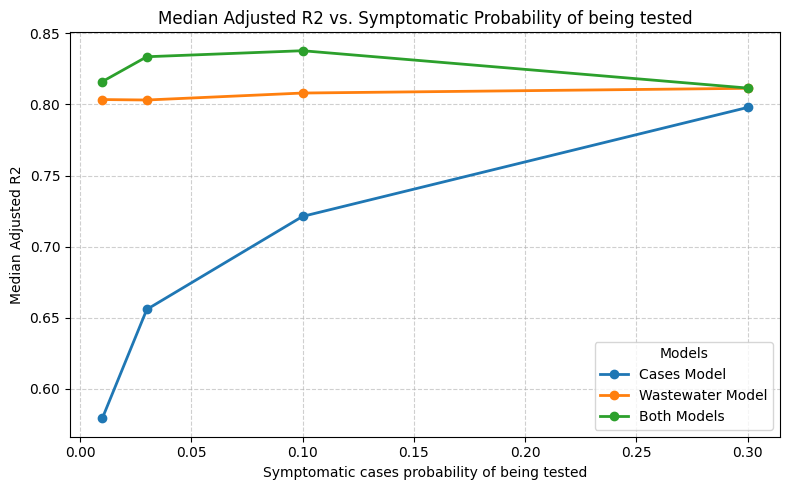

In [14]:
# Assuming your DataFrame is named 'df'
# 1. Filter for rows where param is 'symp_prob'
df_symp = df[df["param"] == "symp_prob"].copy()

# Ensure the x-axis values are numeric
x_vals = pd.to_numeric(df_symp["value"])

# 2. Extract y-values for each model
y_cases = df_symp["median_AdjR2_cases"]
y_ww = df_symp["median_AdjR2_wastewater"]
y_both = df_symp["median_AdjR2_both"]

# 3. Create the plot using pure matplotlib
plt.figure(figsize=(8, 5))

plt.plot(
    x_vals,
    y_cases,
    marker="o",
    linewidth=2,
    label="Cases Model",
    color="#1f77b4",
)
plt.plot(
    x_vals,
    y_ww,
    marker="o",
    linewidth=2,
    label="Wastewater Model",
    color="#ff7f0e",
)
plt.plot(
    x_vals,
    y_both,
    marker="o",
    linewidth=2,
    label="Both Models",
    color="#2ca02c",
)

# 4. Formatting
plt.title(
    "Median Adjusted R2 vs. Symptomatic Probability of being tested", fontsize=12
)
plt.xlabel("Symptomatic cases probability of being tested", fontsize=10)
plt.ylabel("Median Adjusted R2", fontsize=10)
plt.legend(title="Models")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### Small test

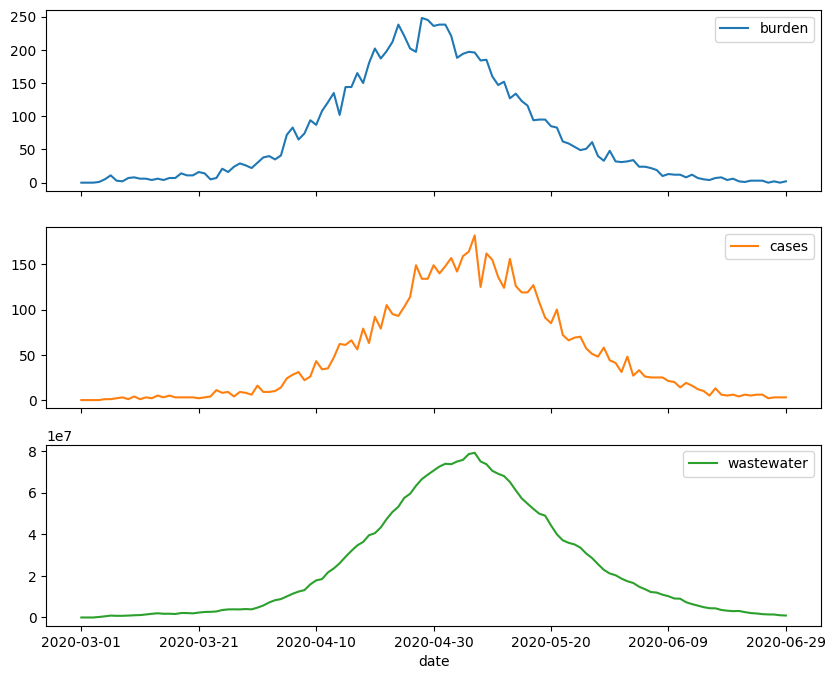

In [10]:
sim = cv.Sim(
  pop_size=POP_SIZE,
  pop_type='hybrid',
  pop_infected=POP_INFECTED,
  location='zambia',
  n_days=N_DAYS,
  n_imports=0,
  interventions=[testing],
  iso_factor=ISO_FACTOR,
  verbose=0,
)
sim.run()

df = extract_wastewater_regression_data(sim)
df.plot(x='date', y=['burden', 'cases', 'wastewater'], subplots=True, figsize=(10, 8))
plt.show()

In [11]:
df

,day,date,burden,cases,wastewater
0,0,2020-03-01,0.0,0.0,0.000000e+00
1,1,2020-03-02,0.0,0.0,0.000000e+00
2,2,2020-03-03,0.0,0.0,0.000000e+00
3,3,2020-03-04,1.0,0.0,2.406838e+05
4,4,2020-03-05,5.0,1.0,5.552730e+05
...,...,...,...,...,...
116,116,2020-06-25,3.0,6.0,1.616785e+06
117,117,2020-06-26,0.0,2.0,1.467470e+06
118,118,2020-06-27,2.0,3.0,1.426809e+06
119,119,2020-06-28,0.0,3.0,1.070073e+06
